# Brisbane’s Housing Affordability Prediction: A Data-Driven Study


## Import Relevant Libraries

In [1]:
# For Data Handling 
import pandas as pd
import numpy as np

# For Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Geospatial Analysis
import geopandas as gpd
import contextily as ctx  # For adding basemaps

# For Modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# System / Path tools
import os


### Importing first dataset extracted from QSC

In [2]:
# Loading the Residential land supply - Queensland extracted from Queensland Spatial Catalogue (QSC)
gdf_land_supply = gpd.read_file("QSC_Extracted_Data.gpkg", ignore_geometry=True)

print("Shape:", gdf_land_supply.shape)
gdf_land_supply.head()

Shape: (18654, 4)


,lga,description,indicativetiming,dwellingyield
0,Livingstone (S),Urban Residential,2 - 5 Years,101 to 500 dwellings
1,Townsville (C),Urban Residential,2 - 5 Years,51 to 100 dwellings
2,Townsville (C),Urban Residential,0 - 2 Years,101 to 500 dwellings
3,Logan (C),Urban Residential,0 - 2 Years,21 to 50 dwellings
4,Townsville (C),Urban Residential,No Timeframe,1 to 5 dwellings


## Preprocessing

In [3]:
# Checking unique values in indicativetiming and dwellingyield
print("Indicative timing:", gdf_land_supply['indicativetiming'].unique())
print("Dwelling yield:", gdf_land_supply['dwellingyield'].unique())
# Checking for missing values
print("Missing values:\n", gdf_land_supply.isnull().sum())

Indicative timing: ['2 - 5 Years' '0 - 2 Years' 'No Timeframe' '5 - 10 Years' '10+ Years']
Dwelling yield: ['101 to 500 dwellings' '51 to 100 dwellings' '21 to 50 dwellings'
 '1 to 5 dwellings' '6 to 20 dwellings' 'Over 500 dwellings']
Missing values:
 lga                 0
description         0
indicativetiming    0
dwellingyield       0
dtype: int64


In [4]:
# Filtering data for Brisbane only
gdf_land_supply = gdf_land_supply[gdf_land_supply['lga'] == 'Brisbane (C)'].copy()

# Mapping dwelling yield ranges to approximate numeric values
yield_mapping = {
    "1 to 5 dwellings": 3,
    "6 to 10 dwellings": 8,
    "11 to 20 dwellings": 15,
    "21 to 50 dwellings": 35,
    "51 to 100 dwellings": 75,
    "101 to 500 dwellings": 300,
    "501 to 1000 dwellings": 750,
    "1001 to 5000 dwellings": 3000,
    "Over 5000 dwellings": 6000,
    "No dwelling yield data": None
}

# Applying mapping
gdf_land_supply['dwelling_yield_approx'] = gdf_land_supply['dwellingyield'].map(yield_mapping)

print("Shape after filtering:", gdf_land_supply.shape)
gdf_land_supply.head()


Shape after filtering: (1216, 5)


,lga,description,indicativetiming,dwellingyield,dwelling_yield_approx
32,Brisbane (C),Urban Residential,2 - 5 Years,101 to 500 dwellings,300.0
33,Brisbane (C),Urban Residential,10+ Years,6 to 20 dwellings,NaN
36,Brisbane (C),Urban Residential,10+ Years,6 to 20 dwellings,NaN
40,Brisbane (C),Urban Residential,5 - 10 Years,101 to 500 dwellings,300.0
87,Brisbane (C),Urban Residential,2 - 5 Years,101 to 500 dwellings,300.0


In [5]:
# Encoding indicativetiming as an ordinal category
timing_mapping = {
    "0 - 2 Years": 1,
    "2 - 5 Years": 2,
    "5 - 10 Years": 3,
    "10+ Years": 4,
    "No Timeframe": 5  
}

gdf_land_supply['timing_category'] = gdf_land_supply['indicativetiming'].map(timing_mapping)

# Drop rows with missing timing or dwelling yield
df_brisbane_cleaned = gdf_land_supply.dropna(subset=['dwelling_yield_approx', 'timing_category'])

print("Shape after cleaning:", df_brisbane_cleaned.shape)
df_brisbane_cleaned[['description', 'dwelling_yield_approx', 'timing_category']].head()


Shape after cleaning: (571, 6)


,description,dwelling_yield_approx,timing_category
32,Urban Residential,300.0,2
40,Urban Residential,300.0,3
87,Urban Residential,300.0,2
115,Urban Residential,3.0,2
118,Urban Residential,3.0,5


In [6]:
# Grouping by land use description and calculate statistics
summary_land_supply = df_brisbane_cleaned.groupby('description').agg({
    'dwelling_yield_approx': ['count', 'sum', 'mean'],
    'timing_category': 'mean'
}).reset_index()

# Renaming columns for clarity
summary_land_supply.columns = ['Land Use Type', 'Number of Areas', 'Total Dwelling Yield', 'Avg Dwelling Yield', 'Avg Timing Category']

summary_land_supply


,Land Use Type,Number of Areas,Total Dwelling Yield,Avg Dwelling Yield,Avg Timing Category
0,Rural Residential,1,3.0,3.000000,1.000000
1,Urban Residential,570,39823.0,69.864912,3.075439


Index(['lga', 'description', 'indicativetiming', 'dwellingyield', 'geometry'], dtype='object')


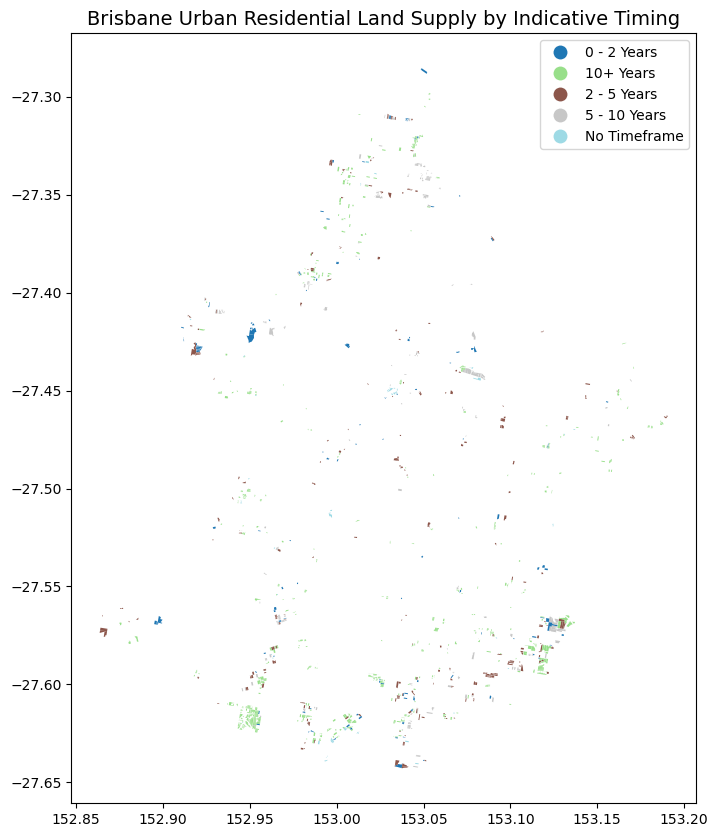

In [7]:
# Loading the full extracted data again
gdf_land_supply = gpd.read_file("QSC_Extracted_Data.gpkg")

# Filter for Brisbane while keeping geometry
brisbane_gdf = gdf_land_supply[gdf_land_supply["lga"].str.contains("Brisbane", case=False)].copy()

print(brisbane_gdf.columns)

# Setting geometry explicitly
brisbane_gdf = gpd.GeoDataFrame(brisbane_gdf, geometry='geometry')

# Plotting with a simple map
fig, ax = plt.subplots(figsize=(10, 10))
brisbane_gdf.plot(column='indicativetiming', legend=True, ax=ax, cmap='tab20')
plt.title("Brisbane Urban Residential Land Supply by Indicative Timing", fontsize=14)
plt.axis('on')
plt.show()


### Importing the shape file for SA2

In [8]:
# Loading the SA2 2021 shapefile using the main .shp file
sa2_gdf = gpd.read_file("SA2_2021_AUST_GDA2020.shp")

print("SA2 GeoDataFrame shape:", sa2_gdf.shape)
print("Columns:", sa2_gdf.columns)
sa2_gdf.head()


SA2 GeoDataFrame shape: (2473, 17)
Columns: Index(['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21',
       'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21',
       'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21',
       'LOCI_URI21', 'geometry'],
      dtype='object')


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.1997 -35.35..."


In [9]:
# Filtering for Queensland only
sa2_qld = sa2_gdf[sa2_gdf['STE_NAME21'] == 'Queensland'].copy()

# Further filtering for Brisbane SA4 regions
brisbane_sa2 = sa2_qld[sa2_qld['SA4_NAME21'].str.contains('Brisbane')].copy()

print("Filtered Brisbane SA2 shape:", brisbane_sa2.shape)
print("Unique SA4 Names:", brisbane_sa2['SA4_NAME21'].unique())
brisbane_sa2.head()


Filtered Brisbane SA2 shape: (138, 17)
Unique SA4 Names: ['Brisbane - East' 'Brisbane - North' 'Brisbane - South' 'Brisbane - West'
 'Brisbane Inner City']


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
1168,301011001,Alexandra Hills,0,No change,30101,Capalaba,301,Brisbane - East,3GBRI,Greater Brisbane,3,Queensland,AUS,Australia,13.6312,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((153.21149 -27.52131, 153.2116 -27.52..."
1169,301011002,Belmont - Gumdale,0,No change,30101,Capalaba,301,Brisbane - East,3GBRI,Greater Brisbane,3,Queensland,AUS,Australia,33.1072,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((153.17138 -27.4855, 153.1714 -27.485..."
1170,301011003,Birkdale,0,No change,30101,Capalaba,301,Brisbane - East,3GBRI,Greater Brisbane,3,Queensland,AUS,Australia,11.5988,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((153.21209 -27.48882, 153.21195 -27.4..."
1171,301011004,Capalaba,0,No change,30101,Capalaba,301,Brisbane - East,3GBRI,Greater Brisbane,3,Queensland,AUS,Australia,18.8892,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((153.17566 -27.53336, 153.17573 -27.5..."
1172,301011005,Thorneside,0,No change,30101,Capalaba,301,Brisbane - East,3GBRI,Greater Brisbane,3,Queensland,AUS,Australia,2.6658,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((153.19708 -27.48113, 153.19746 -27.4..."


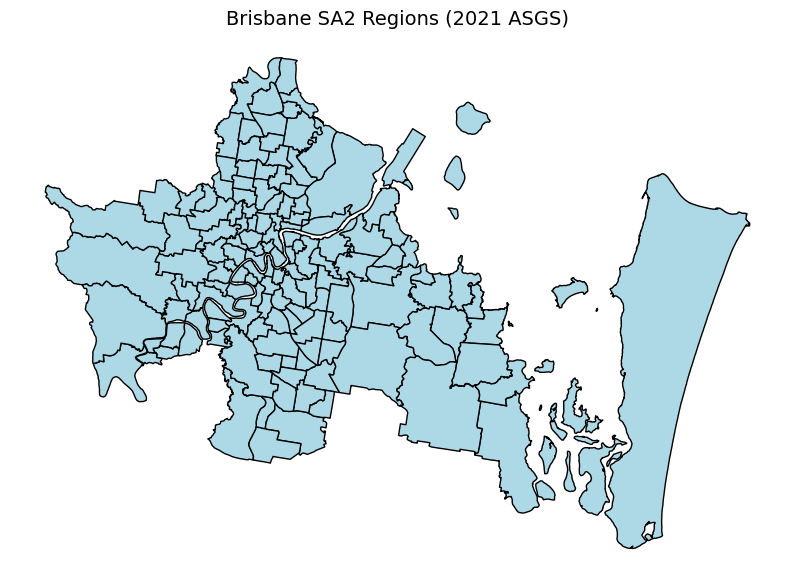

In [10]:
# Plotting Brisbane SA2 regions
fig, ax = plt.subplots(figsize=(10, 10))
brisbane_sa2.plot(ax=ax, edgecolor='black', facecolor='lightblue')
plt.title("Brisbane SA2 Regions (2021 ASGS)", fontsize=14)
plt.axis('off')
plt.show()


### Merging both the datasets

In [11]:
print("Land Supply CRS:", brisbane_gdf.crs) # coordinate reference system
print("SA2 Brisbane CRS:", brisbane_sa2.crs)


Land Supply CRS: EPSG:4283
SA2 Brisbane CRS: EPSG:7844


In [12]:
# Reproject land supply GeoDataFrame to match SA2 CRS
brisbane_gdf = brisbane_gdf.to_crs(epsg=7844)

# Confirming if CRS matches
print("Updated Land Supply CRS:", brisbane_gdf.crs)


Updated Land Supply CRS: EPSG:7844


In [13]:
# Performing spatial join to map each land parcel to its SA2 region
gdf_land_with_sa2 = gpd.sjoin(
    brisbane_gdf, 
    brisbane_sa2[['SA2_NAME21', 'SA2_CODE21', 'geometry']], 
    how='left', 
    predicate='intersects'
)

print("Joined shape:", gdf_land_with_sa2.shape)
gdf_land_with_sa2.head()


Joined shape: (1220, 8)


,lga,description,indicativetiming,dwellingyield,geometry,index_right,SA2_NAME21,SA2_CODE21
32,Brisbane (C),Urban Residential,2 - 5 Years,101 to 500 dwellings,"MULTIPOLYGON (((153.03968 -27.49061, 153.03965...",1226.0,Woolloongabba,303021058
33,Brisbane (C),Urban Residential,10+ Years,6 to 20 dwellings,"MULTIPOLYGON (((153.12414 -27.50075, 153.12393...",1219.0,Carindale,303011051
36,Brisbane (C),Urban Residential,10+ Years,6 to 20 dwellings,"MULTIPOLYGON (((152.94621 -27.61887, 152.94579...",NaN,NaN,NaN
40,Brisbane (C),Urban Residential,5 - 10 Years,101 to 500 dwellings,"MULTIPOLYGON (((153.03785 -27.45677, 153.03785...",1274.0,Fortitude Valley,305011106
87,Brisbane (C),Urban Residential,2 - 5 Years,101 to 500 dwellings,"MULTIPOLYGON (((153.04891 -27.45177, 153.04883...",1296.0,Newstead - Bowen Hills,305031128


### Summarise Land Supply by SA2

In [14]:
# Merging engineered columns from df_brisbane_cleaned to gdf_land_with_sa2
gdf_land_with_sa2 = gdf_land_with_sa2.merge(
    df_brisbane_cleaned[['description', 'dwellingyield', 'indicativetiming', 'dwelling_yield_approx', 'timing_category']],
    on=['description', 'dwellingyield', 'indicativetiming'],
    how='left'
)


In [15]:
# Grouping and summarising by SA2
sa2_summary = gdf_land_with_sa2.groupby(['SA2_CODE21', 'SA2_NAME21']).agg({
    'dwelling_yield_approx': ['count', 'sum', 'mean'],
    'timing_category': 'mean'
}).reset_index()

# Renaming the columns for clarity
sa2_summary.columns = [
    'SA2_CODE21', 'SA2_NAME21',
    'Parcel_Count', 'Total_Dwelling_Yield', 'Avg_Dwelling_Yield',
    'Avg_Timing_Category'
]

# Summary
print("SA2-level summary shape:", sa2_summary.shape)
sa2_summary.head()


SA2-level summary shape: (92, 6)


,SA2_CODE21,SA2_NAME21,Parcel_Count,Total_Dwelling_Yield,Avg_Dwelling_Yield,Avg_Timing_Category
0,301011002,Belmont - Gumdale,146,438.0,3.000000,4.000000
1,301031015,Manly - Lota,328,11676.0,35.597561,3.780488
2,301031016,Manly West,253,4183.0,16.533597,3.581028
3,301031017,Murarrie,169,16535.0,97.840237,2.000000
4,301031018,Tingalpa,358,2802.0,7.826816,4.033520


In [16]:
# Saving the sa2 summary so that it can be used later
sa2_summary.to_csv("sa2_land_supply_summary.csv", index=False)

In [17]:
# Saving the cleaned data so that it can be used later
df_brisbane_cleaned.to_csv("brisbane_cleaned_land_supply.csv", index=False)


### Exploratory Data Analysis

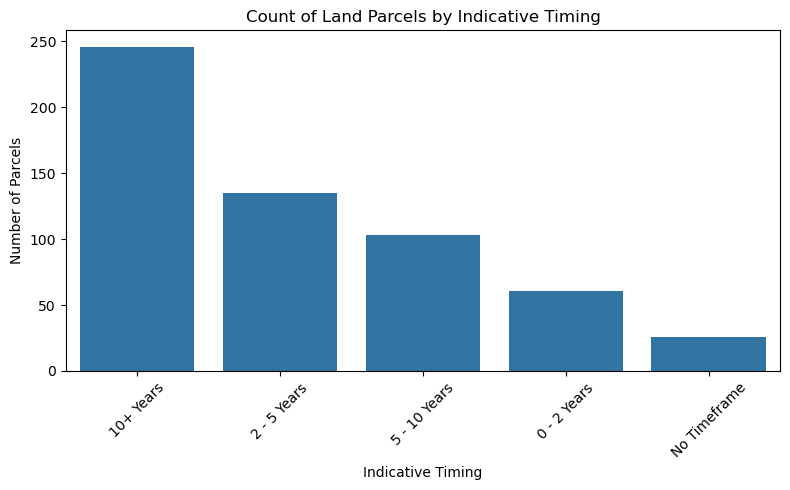

In [18]:
# Count of Land Parcels by Indicative Timing
plt.figure(figsize=(8, 5))
sns.countplot(data=df_brisbane_cleaned, x='indicativetiming', order=df_brisbane_cleaned['indicativetiming'].value_counts().index)
plt.title("Count of Land Parcels by Indicative Timing")
plt.xlabel("Indicative Timing")
plt.ylabel("Number of Parcels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


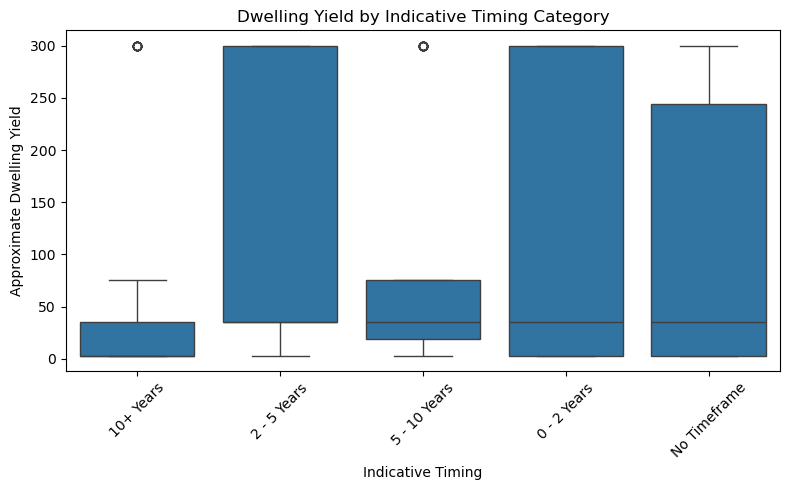

In [19]:
# Dwelling Yield Distribution by Indicative Timing
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_brisbane_cleaned, x='indicativetiming', y='dwelling_yield_approx', order=df_brisbane_cleaned['indicativetiming'].value_counts().index)
plt.title("Dwelling Yield by Indicative Timing Category")
plt.xlabel("Indicative Timing")
plt.ylabel("Approximate Dwelling Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Linear Regression Model 

In [20]:
# Loading the cleaned CSV that we saved earlier
df = pd.read_csv("brisbane_cleaned_land_supply.csv")

# Dropping rows with missing values in key columns
df = df.dropna(subset=['dwelling_yield_approx', 'timing_category', 'description'])

# One-hot encoding 'description'
df_encoded = pd.get_dummies(df, columns=['description'], drop_first=True)

# Defining X (features) and y (target), only keeping numeric columns for target
X = df_encoded.drop(columns=['lga', 'indicativetiming', 'dwellingyield', 'dwelling_yield_approx'])
y = df_encoded['dwelling_yield_approx']

# Splitting into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the Linear model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions and metrics
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} dwellings")
print(f"R² Score: {r2:.3f}")


Mean Absolute Error (MAE): 79.14 dwellings
R² Score: 0.044


**Interpretation**

The model has very low predictive power using just:
- timing_category (0–2 years, 2–5 years, etc.)
- description (land use type)

This is expected because land supply is likely influenced by other important features like:
- Population projections
- Land area size
- Zoning policies
- Infrastructure accessibility
- Past development trends

### Merging SA2 land supply data with SA2 population projections

In [21]:
import pandas as pd

# Loading both the datasets
land_supply_df = pd.read_csv("sa2_land_supply_summary.csv")
population_df = pd.read_csv("qld_population_cleaned.csv")

# Checking columns before joining 
print("Land Supply columns:", land_supply_df.columns)
print("Population columns:", population_df.columns)


Land Supply columns: Index(['SA2_CODE21', 'SA2_NAME21', 'Parcel_Count', 'Total_Dwelling_Yield',
       'Avg_Dwelling_Yield', 'Avg_Timing_Category'],
      dtype='object')
Population columns: Index(['SA2_code', 'SA2_name', '2021', '2026', '2031', '2036', '2041', '2046'], dtype='object')


In [22]:
print("Land Supply Columns:")
print(land_supply_df.columns)

print("\nPopulation Columns:")
print(population_df.columns)


Land Supply Columns:
Index(['SA2_CODE21', 'SA2_NAME21', 'Parcel_Count', 'Total_Dwelling_Yield',
       'Avg_Dwelling_Yield', 'Avg_Timing_Category'],
      dtype='object')

Population Columns:
Index(['SA2_code', 'SA2_name', '2021', '2026', '2031', '2036', '2041', '2046'], dtype='object')


In [23]:
# Renaming the column in population_df to match land_supply_df
population_df.rename(columns={'SA2_name': 'SA2_NAME21'}, inplace=True)

# Standardizing the case and removing any whitespaces
land_supply_df['SA2_NAME21'] = land_supply_df['SA2_NAME21'].str.lower().str.strip()
population_df['SA2_NAME21'] = population_df['SA2_NAME21'].str.lower().str.strip()

# Merging the datasets on SA2_NAME21
merged_df = pd.merge(land_supply_df, population_df, on='SA2_NAME21', how='inner')

print("Merged shape:", merged_df.shape)
merged_df.head()


Merged shape: (92, 13)


,SA2_CODE21,SA2_NAME21,Parcel_Count,Total_Dwelling_Yield,Avg_Dwelling_Yield,Avg_Timing_Category,SA2_code,2021,2026,2031,2036,2041,2046
0,301011002,belmont - gumdale,146,438.0,3.000000,4.000000,301011002.0,7645.0,7338.076987,7165.525279,7024.175951,6946.417474,6902.367932
1,301031015,manly - lota,328,11676.0,35.597561,3.780488,301031015.0,7993.0,8054.912923,8167.228434,8318.511560,8545.208606,8705.336014
2,301031016,manly west,253,4183.0,16.533597,3.581028,301031016.0,12026.0,12253.500673,12313.593162,12362.769184,12469.010267,12569.058529
3,301031017,murarrie,169,16535.0,97.840237,2.000000,301031017.0,4843.0,4750.123928,4812.062551,5049.047274,5335.953957,5689.998653
4,301031018,tingalpa,358,2802.0,7.826816,4.033520,301031018.0,8992.0,9447.939650,10002.026733,10342.550336,10590.624703,10719.634096


In [24]:
# Saving the merged file 
merged_df.to_csv("brisbane_sa2_merged.csv", index=False)

#### Calculating Population Growth

In [25]:
# Projected population growth from 2021 to 2046
merged_df['pop_growth_2021_2046'] = merged_df['2046'] - merged_df['2021']

# Growth rate as a percentage
merged_df['pop_growth_%'] = ((merged_df['2046'] - merged_df['2021']) / merged_df['2021']) * 100

merged_df[['SA2_NAME21', '2021', '2046', 'pop_growth_2021_2046', 'pop_growth_%']].head()


,SA2_NAME21,2021,2046,pop_growth_2021_2046,pop_growth_%
0,belmont - gumdale,7645.0,6902.367932,-742.632068,-9.713958
1,manly - lota,7993.0,8705.336014,712.336014,8.911998
2,manly west,12026.0,12569.058529,543.058529,4.515704
3,murarrie,4843.0,5689.998653,846.998653,17.489132
4,tingalpa,8992.0,10719.634096,1727.634096,19.213013


In [26]:
# Correlation matrix
correlation = merged_df[['Total_Dwelling_Yield', 'Avg_Timing_Category', 'pop_growth_2021_2046']].corr()
print(correlation)

                      Total_Dwelling_Yield  Avg_Timing_Category  \
Total_Dwelling_Yield              1.000000            -0.093664   
Avg_Timing_Category              -0.093664             1.000000   
pop_growth_2021_2046              0.537220            -0.200154   

                      pop_growth_2021_2046  
Total_Dwelling_Yield              0.537220  
Avg_Timing_Category              -0.200154  
pop_growth_2021_2046              1.000000  


### Feature Engineering for Modeling

In [27]:
# Loading the merged dataset
df = pd.read_csv("brisbane_sa2_merged.csv")

# Feature 1: Dwelling yield per capita (based on 2026 or 2031 population)
df['dwelling_yield_per_capita_2026'] = df['Total_Dwelling_Yield'] / df['2026']
df['dwelling_yield_per_capita_2031'] = df['Total_Dwelling_Yield'] / df['2031']

# Feature 2: Dwelling gap estimate (gap between future population growth and current supply)
# Simple assumption: 1 dwelling needed per 2.5 people
df['estimated_dwelling_need_2031'] = (df['2031'] - df['2021']) / 2.5
df['dwelling_gap'] = df['estimated_dwelling_need_2031'] - df['Total_Dwelling_Yield']

# Preview the data
df[['SA2_NAME21', 'Total_Dwelling_Yield', '2031', 'dwelling_yield_per_capita_2031', 
      'dwelling_gap']].head()


,SA2_NAME21,Total_Dwelling_Yield,2031,dwelling_yield_per_capita_2031,dwelling_gap
0,belmont - gumdale,438.0,7165.525279,0.061126,-629.789888
1,manly - lota,11676.0,8167.228434,1.429616,-11606.308626
2,manly west,4183.0,12313.593162,0.339706,-4067.962735
3,murarrie,16535.0,4812.062551,3.436156,-16547.374980
4,tingalpa,2802.0,10002.026733,0.280143,-2397.989307


## Random Forest Regressor

In [28]:
# Load the dataset
df = pd.read_csv("brisbane_sa2_merged.csv")

# Simplified Feature Set
features = ['Parcel_Count', 'Avg_Dwelling_Yield', '2031']
target = 'Total_Dwelling_Yield'

# Drop missing values
df_model = df[features + [target]].dropna()

# Split data
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 5756.443333333333
MSE: 153194095.48762217
R² Score: 0.48883231204071487


## Random Forest Classifier

In [29]:
# Categorize dwelling yield
def categorize_yield(y):
    if y < 3000:
        return "Low"
    elif y < 10000:
        return "Medium"
    else:
        return "High"

df['yield_category'] = df['Total_Dwelling_Yield'].apply(categorize_yield)

# Features and target
features = ['Parcel_Count', 'Avg_Dwelling_Yield', '2031']
target = 'yield_category'

# Drop NAs
df_class = df[features + [target]].dropna()

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_class['yield_category_encoded'] = le.fit_transform(df_class['yield_category'])

# Train-test split
X = df_class[features]
y = df_class['yield_category_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import classification_report
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

        High       0.80      1.00      0.89         8
         Low       1.00      0.86      0.92         7
      Medium       0.50      0.33      0.40         3

    accuracy                           0.83        18
   macro avg       0.77      0.73      0.74        18
weighted avg       0.83      0.83      0.82        18



- We trained both regression and classification models. The regression model provides moderate predictive accuracy (R² = 0.49) and is more suitable when estimating numeric outcomes. The classifier, with 83% accuracy, excels at distinguishing low/high-yield areas but struggles with rare categories like medium-yield. Together, these models support a multi-level decision-making framework — providing both precise and categorical insights for urban planning.

## Visualisations

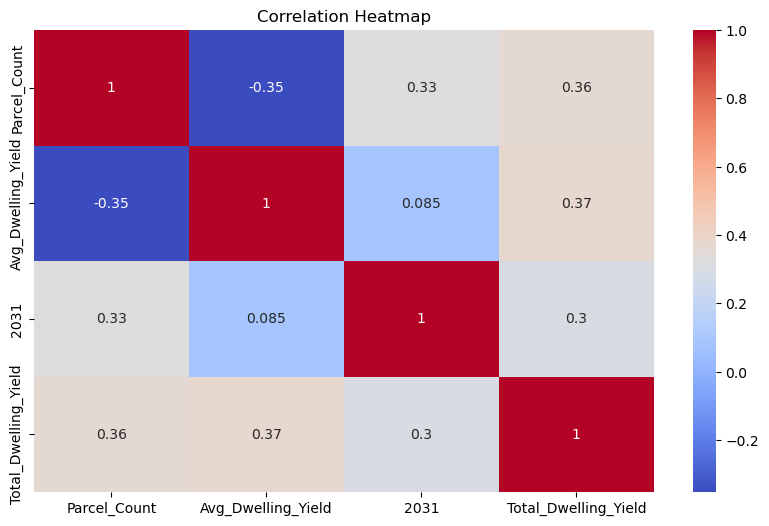

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Feature Importance (for Regression)

/var/folders/rj/fkzxb53x24n764r_dxmmkd600000gn/T/ipykernel_21786/3612041740.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis')


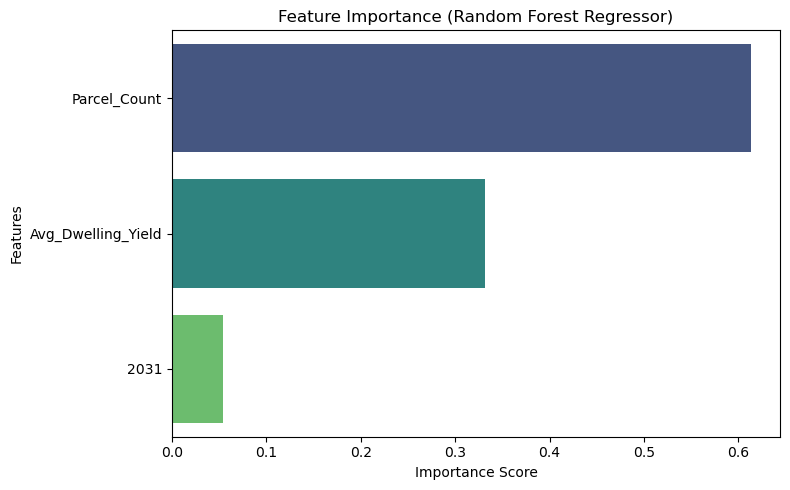

In [31]:
# Getting feature importances from the trained model
importances = model.feature_importances_

# DataFrame for plotting
feat_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis')
plt.title("Feature Importance (Random Forest Regressor)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()



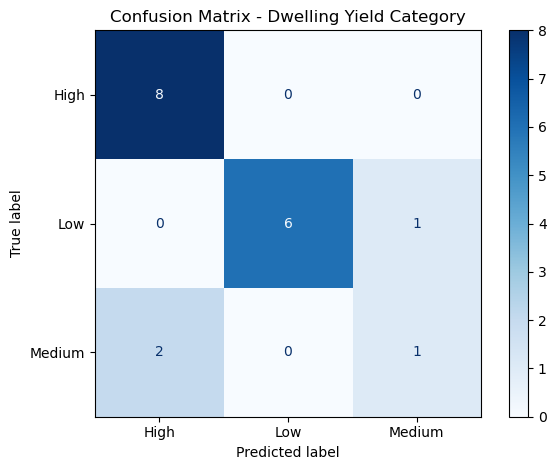

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

# Displaying the confusion matrix using existing test data
ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    display_labels=le.classes_,
    cmap='Blues'
)
plt.title("Confusion Matrix - Dwelling Yield Category")
plt.tight_layout()
plt.show()



In [33]:
df = pd.read_csv("brisbane_sa2_merged.csv")
print(df.columns)
df.head()

Index(['SA2_CODE21', 'SA2_NAME21', 'Parcel_Count', 'Total_Dwelling_Yield',
       'Avg_Dwelling_Yield', 'Avg_Timing_Category', 'SA2_code', '2021', '2026',
       '2031', '2036', '2041', '2046'],
      dtype='object')


,SA2_CODE21,SA2_NAME21,Parcel_Count,Total_Dwelling_Yield,Avg_Dwelling_Yield,Avg_Timing_Category,SA2_code,2021,2026,2031,2036,2041,2046
0,301011002,belmont - gumdale,146,438.0,3.000000,4.000000,301011002.0,7645.0,7338.076987,7165.525279,7024.175951,6946.417474,6902.367932
1,301031015,manly - lota,328,11676.0,35.597561,3.780488,301031015.0,7993.0,8054.912923,8167.228434,8318.511560,8545.208606,8705.336014
2,301031016,manly west,253,4183.0,16.533597,3.581028,301031016.0,12026.0,12253.500673,12313.593162,12362.769184,12469.010267,12569.058529
3,301031017,murarrie,169,16535.0,97.840237,2.000000,301031017.0,4843.0,4750.123928,4812.062551,5049.047274,5335.953957,5689.998653
4,301031018,tingalpa,358,2802.0,7.826816,4.033520,301031018.0,8992.0,9447.939650,10002.026733,10342.550336,10590.624703,10719.634096


### Exporting the clean data

In [34]:
# Loading the working dataset
df = pd.read_csv("brisbane_sa2_merged.csv")

# Calculating dwelling gap to add in the final exported dataset
if 'dwelling_gap' not in df.columns:
    df['estimated_dwelling_need_2031'] = (df['2031'] - df['2021']) / 2.5
    df['dwelling_gap'] = df['estimated_dwelling_need_2031'] - df['Total_Dwelling_Yield']

# Selecting relevant columns including dwelling_gap
final_columns = [
    'SA2_CODE21', 'SA2_NAME21',
    'Parcel_Count', 'Total_Dwelling_Yield', 'Avg_Dwelling_Yield', 'Avg_Timing_Category',
    '2021', '2026', '2031', '2036', '2041', '2046',
    'dwelling_gap'
]

df_final = df[final_columns]

# Exporting final CSV
df_final.to_csv("brisbane_final_cleaned.csv", index=False)
print("✅ Exported: brisbane_final_cleaned.csv")

✅ Exported: brisbane_final_cleaned.csv
